In [ ]:
# %% [1] install
%pip -q install easyocr pillow requests numpy matplotlib

# %% [2] imports
import os, re, io
import requests
import numpy as np
from PIL import Image
import easyocr

# %% [3] message IDs
messageIds = [
    "019b2a64-eebc-7815-84c5-e384fabc495c",
    "019a48ff-b175-783c-93fc-b4ec6731dde5",
    "019bb6b8-5c57-7d1f-8b93-297c8e6c7827",
    "019bb5c0-5409-7b3b-ba9b-07449030364a",
    "019bd043-d86c-79b8-9cf1-11351a482267",
    "0197c4ef-8be2-792e-922b-c498b6948775",
    "01963951-0f55-75b5-a53b-07f467ad9051",
    "0195be37-dea6-7902-8d04-e46185873108",
    "019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa",
    "019bde55-b166-7d7b-b290-2f049f72fe08",
    "019bbd0d-5e27-77b2-8494-42499697c033",
    "019bde84-1609-7dc5-b8fc-f2c77bcdb005",
    "019bdeb4-6ec8-7e0e-b773-3bec85c35584",
    "019bb65e-9263-7c89-b123-95389f4414cd",
    "019b8cea-695d-7047-aafb-793c58d25eff",
]

# %% [4] r_session input
r_session = input("r_session を入力してください: ").strip()
if not r_session:
    raise RuntimeError("r_session が空です")

# %% [5] traQ fetch
BASE_URL = "https://q.trap.jp/api/v3"
_FILE_URL_RE = re.compile(r"https?://q\.trap\.jp/files/([0-9a-fA-F-]+)")

def _get_session() -> requests.Session:
    s = requests.Session()
    s.cookies.set("r_session", r_session)
    return s

def get_messages_and_images(message_ids):
    """
    returns:
      messages: list[str] (画像URL除去済み本文)
      images:   list[list[PIL.Image]] (messageごとの画像配列)
    """
    messages, images = [], []
    with _get_session() as session:
        for mid in message_ids:
            resp = session.get(f"{BASE_URL}/messages/{mid}")
            resp.raise_for_status()
            content = resp.json()["content"]

            file_ids = _FILE_URL_RE.findall(content)
            imgs = []
            for fid in file_ids:
                r = session.get(f"{BASE_URL}/files/{fid}")
                r.raise_for_status()
                imgs.append(Image.open(io.BytesIO(r.content)).convert("RGB"))

            text = _FILE_URL_RE.sub("", content).strip()
            messages.append(text)
            images.append(imgs)
    return messages, images

messages, images = get_messages_and_images(messageIds)
print("messages:", len(messages))
print("msgs with images:", sum(1 for x in images if len(x) > 0))

# %% [6] EasyOCR init
# gpu=True にすると速いことが多い（ColabでCUDA使えるなら）
reader = easyocr.Reader(["ja", "en"], gpu=False, download_enabled=True)

def upscale_for_ocr(pil_img: Image.Image, scale: int = 2) -> Image.Image:
    w, h = pil_img.size
    return pil_img.resize((w * scale, h * scale), Image.BICUBIC)

def ocr_pil_image(pil_img: Image.Image, scale=2, conf_th=0.4) -> str:
    arr = np.array(upscale_for_ocr(pil_img, scale=scale))
    results = reader.readtext(arr, detail=1, paragraph=False)

    lines = []
    for _bbox, text, conf in results:
        if conf < conf_th:
            continue
        t = str(text).strip()
        if not t:
            continue
        t = re.sub(r"\s+", " ", t)
        lines.append(t)

    # 重複除去（順序維持）
    uniq, seen = [], set()
    for t in lines:
        if t in seen:
            continue
        seen.add(t)
        uniq.append(t)

    return "\n".join(uniq).strip()

# %% [7] run OCR -> (labels, ocr_texts, thumbnails)
labels, ocr_texts, thumbnails = [], [], []
THUMB_SIZE = 1000

for m_idx, (msg, imgs) in enumerate(zip(messages, images), start=1):
    for i_idx, img in enumerate(imgs, start=1):
        label = f"M{m_idx}-I{i_idx}"
        ocr = ocr_pil_image(img, scale=2, conf_th=0.4)

        labels.append(label)
        ocr_texts.append(ocr)

        thumb = img.copy()
        thumb.thumbnail((THUMB_SIZE, THUMB_SIZE))
        thumbnails.append(np.array(thumb))

print("docs:", len(labels))

# %% [8] OCR gallery
import matplotlib.pyplot as plt
import textwrap, math

def show_ocr_gallery(thumbnails, labels, ocr_texts, cols=3, per_page=12, ocr_chars=250):
    assert len(thumbnails) == len(labels) == len(ocr_texts)
    n = len(labels)
    if n == 0:
        print("画像がありません")
        return
    pages = math.ceil(n / per_page)

    for p in range(pages):
        start = p * per_page
        end = min(n, (p + 1) * per_page)
        m = end - start
        rows = math.ceil(m / cols)

        fig = plt.figure(figsize=(cols * 5, rows * 4))
        for k in range(m):
            doc_idx = start + k
            ax = fig.add_subplot(rows, cols, k + 1)
            ax.imshow(thumbnails[doc_idx])
            ax.axis("off")

            ocr = (ocr_texts[doc_idx] or "").strip()
            if len(ocr) > ocr_chars:
                ocr = ocr[:ocr_chars] + "…"
            if not ocr:
                ocr = "(OCRなし)"

            ax.set_title(labels[doc_idx], fontsize=10)
            ax.text(
                0.01, -0.05,
                textwrap.fill(ocr, width=38),
                transform=ax.transAxes,
                fontsize=9,
                va="top",
                ha="left",
            )

        fig.suptitle(f"OCR Gallery Page {p+1}/{pages}", fontsize=14)
        plt.tight_layout()
        plt.show()

show_ocr_gallery(thumbnails, labels, ocr_texts, cols=3, per_page=12, ocr_chars=250)

In [2]:
# ヒートマップで可視化
import warnings

# 日本語フォントの設定（Google Colab用）
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# フォントキャッシュをクリアして再構築
font_manager.fontManager.addfont('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
matplotlib.rcParams['font.family'] = 'Noto Sans CJK JP'

# フォント関連の警告を抑制
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

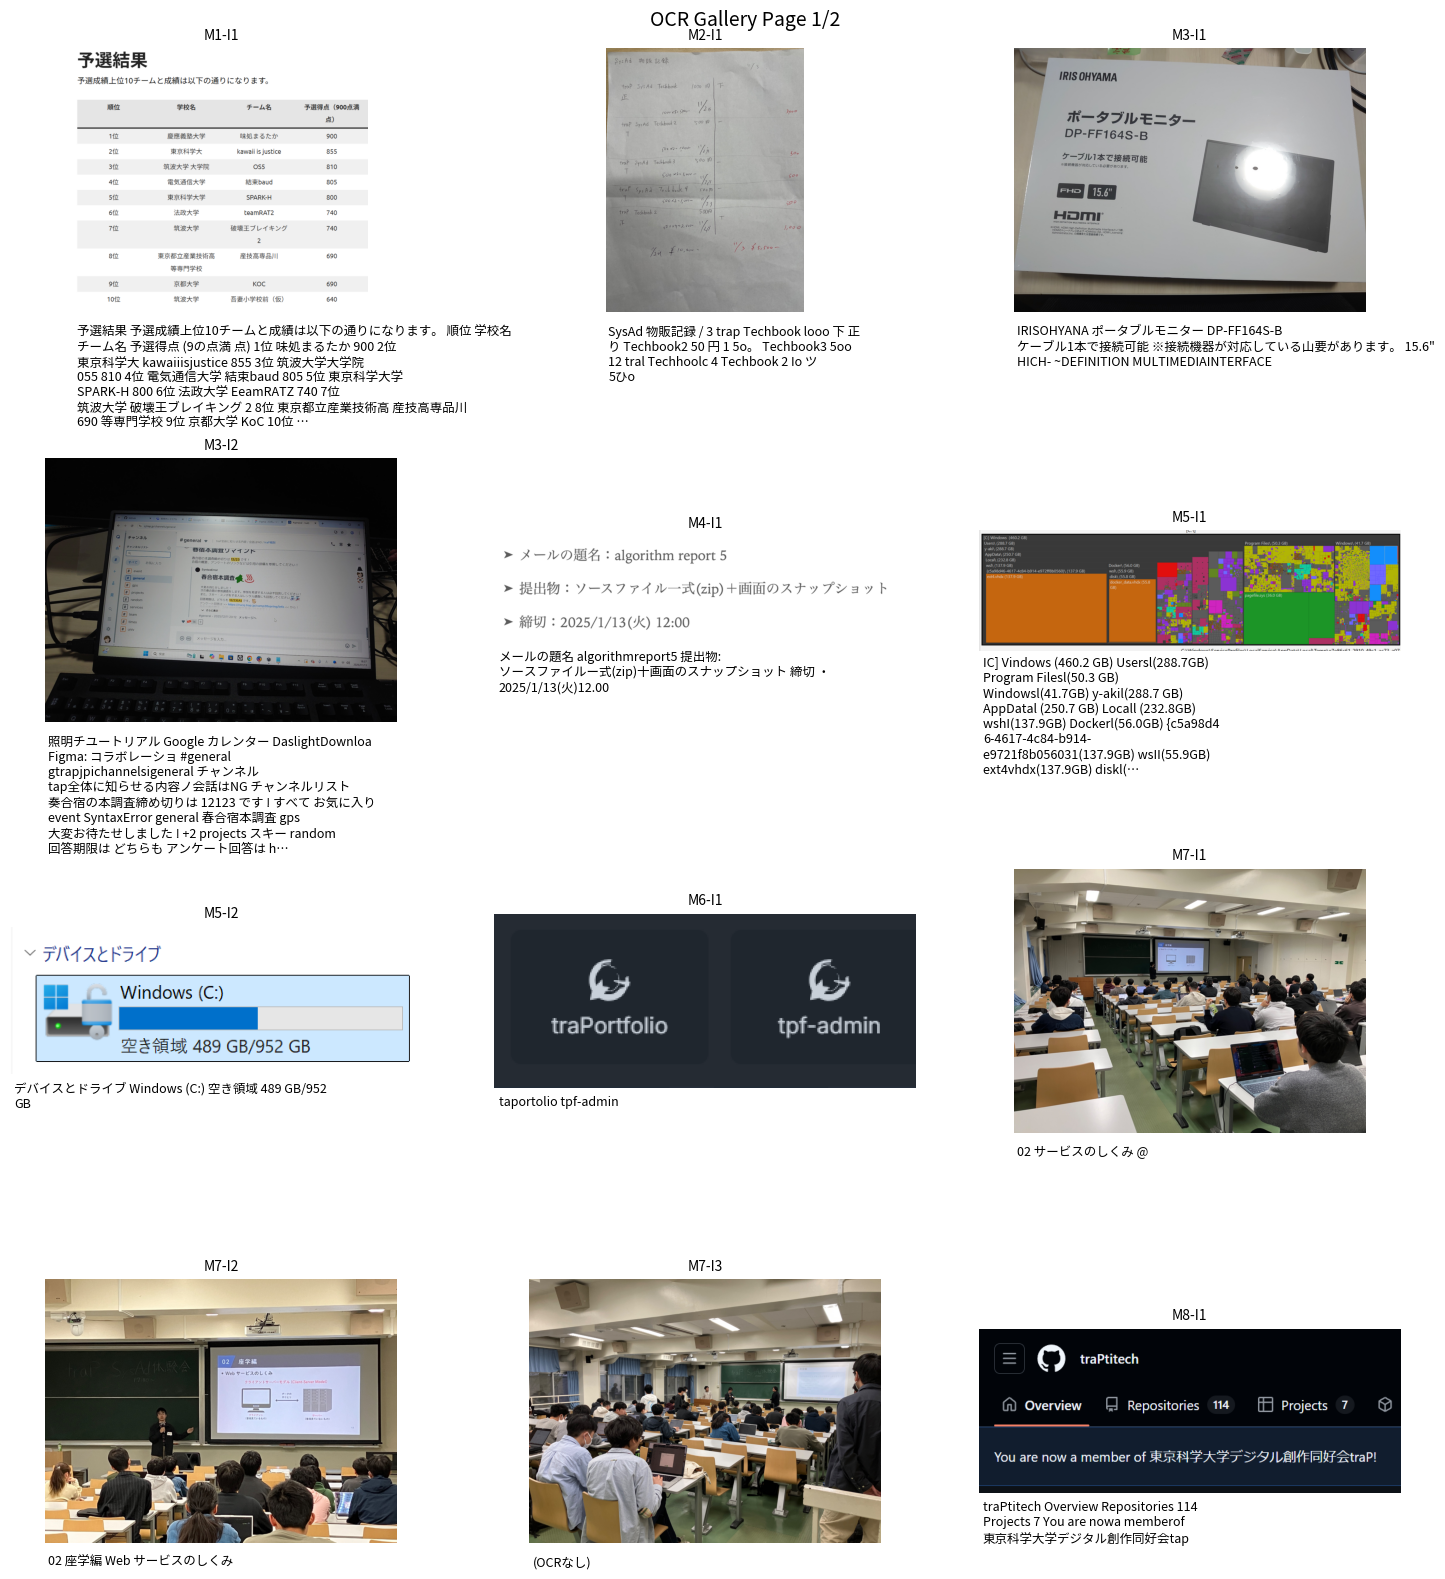

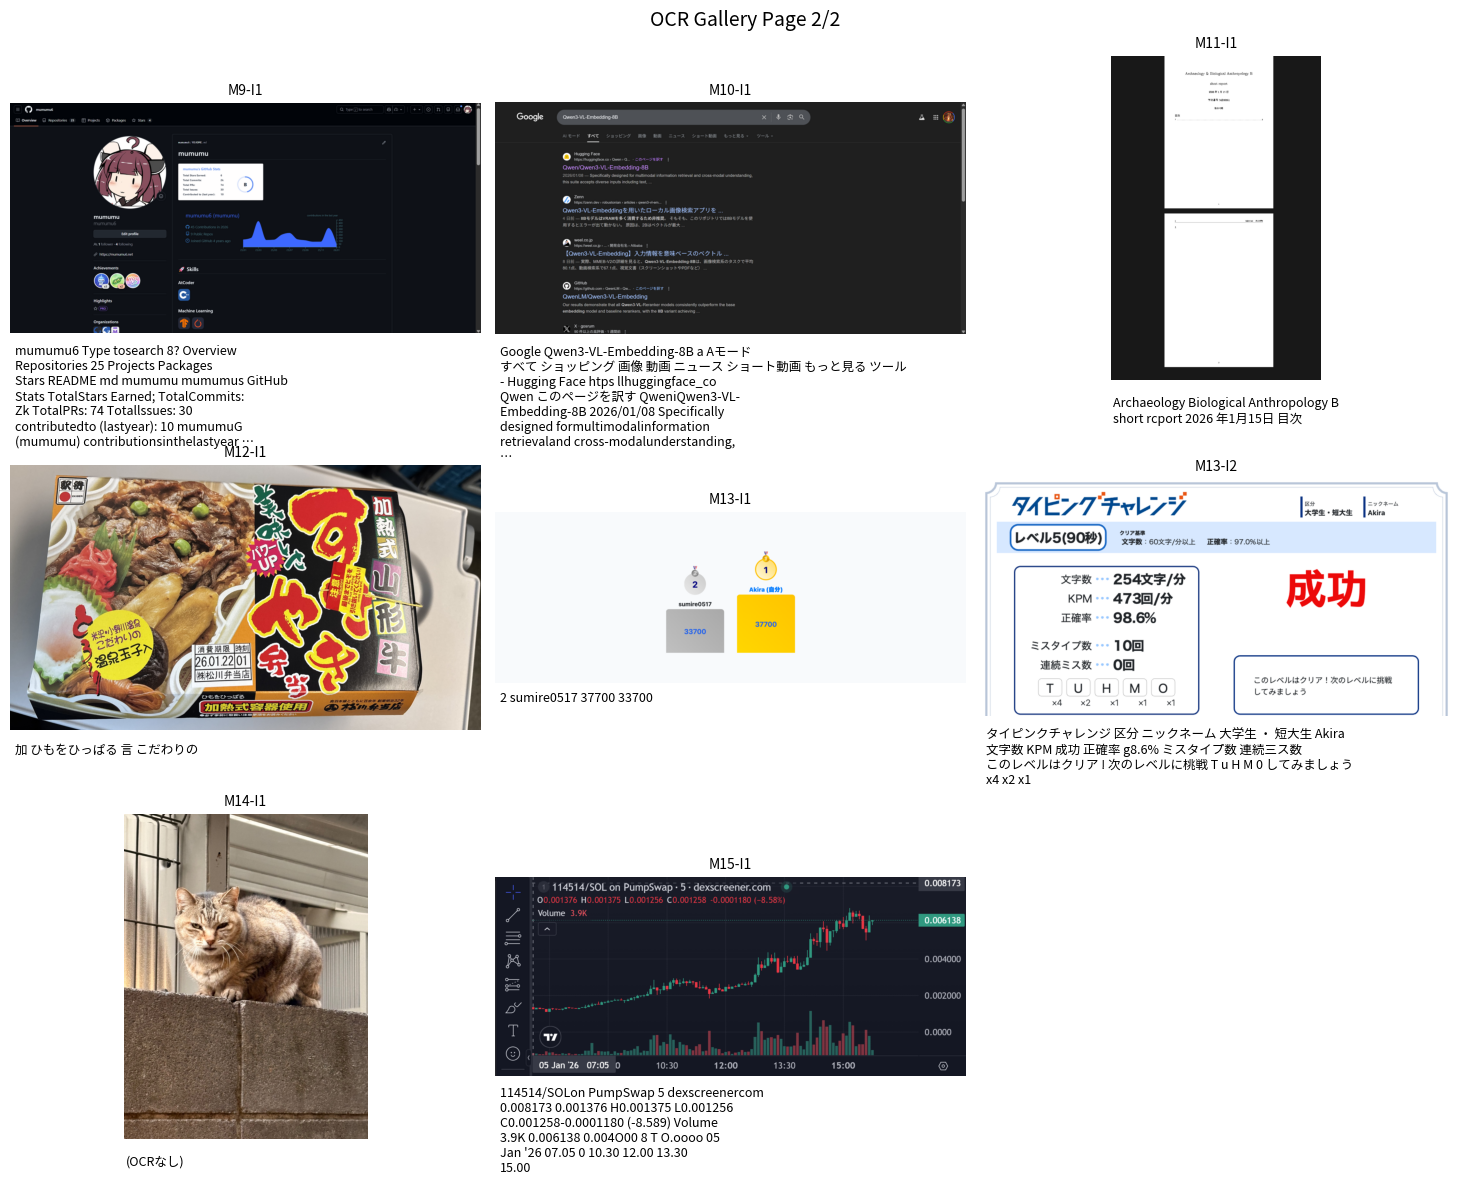

In [3]:
show_ocr_gallery(thumbnails, labels, ocr_texts, cols=3, per_page=12, ocr_chars=250)